# Titanic Dataset — Exploratory Data Analysis
Author: Ranmini Peiris  
Date: 09/14/2026 
Goal: Understand survival patterns and produce a cleaned dataset for downstream modeling.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

sys.path.append("../src")
from clean import load_data, clean_titanic

In [7]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Cleaning Steps
1. Dropped `Cabin` (>77% missing), `Ticket`, `Name`, `PassengerId` (no predictive value).
2. Filled `Age` with median grouped by `Pclass` + `Sex` — preserves cohort signal.
3. Filled `Embarked` (2 missing) with the mode (`S`).
4. Engineered features:
   - `FamilySize = SibSp + Parch + 1`
   - `IsAlone` flag
   - `AgeGroup` bins (Child/Teen/YoungAdult/Adult/Senior)
   - `FarePerPerson = Fare / FamilySize`
5. Encoded `Sex` (0/1) and one-hot encoded `Embarked`, `AgeGroup`.

In [8]:
df = clean_titanic(df_raw)
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/cleaned_titanic.csv", index=False)
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
df.head()

Shape: (891, 16)
Nulls: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,False,True,False,True,False,False
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,False,False,False,False,True,False
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,False,True,False,True,False,False
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,False,True,False,True,False,False
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,False,True,False,True,False,False


## 1. Survival Rate by Class and Gender

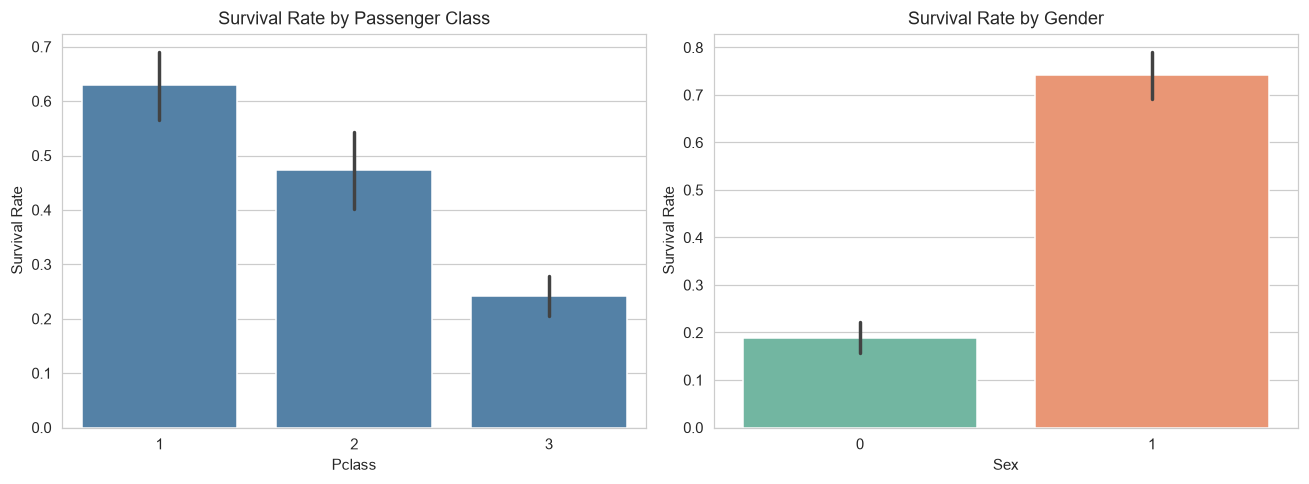

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# By class
sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[0], color="steelblue")
axes[0].set_title("Survival Rate by Passenger Class")
axes[0].set_ylabel("Survival Rate")

# By gender — using hue to avoid the deprecation
sns.barplot(x="Sex", y="Survived", data=df, ax=axes[1], hue="Sex",
            palette="Set2", legend=False)
axes[1].set_title("Survival Rate by Gender")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("../charts/survival_by_class_gender.png", bbox_inches="tight")
plt.show()

## 2. Age Distribution

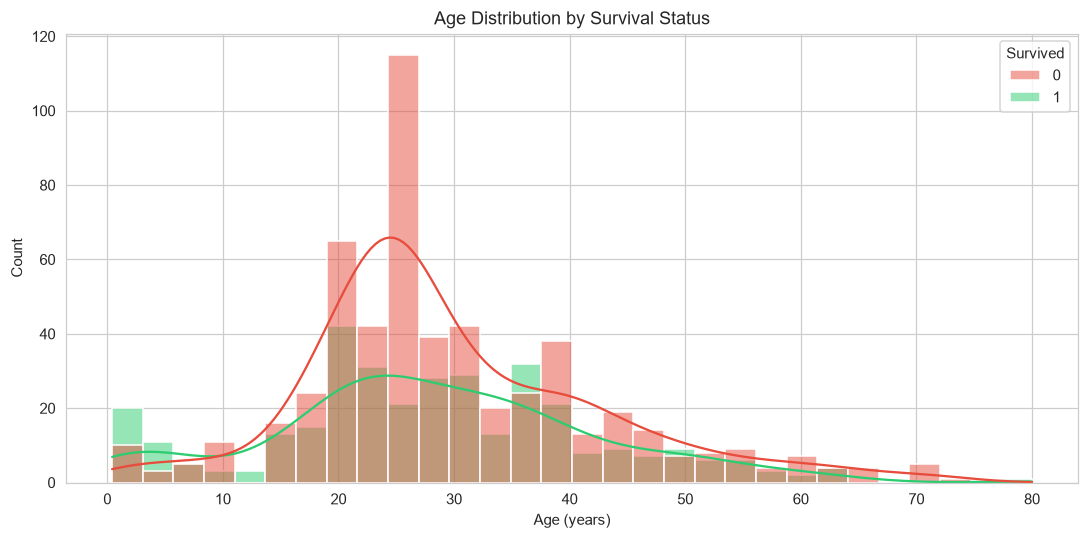

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="Age", hue="Survived", kde=True, bins=30,
             palette={0: "#e74c3c", 1: "#2ecc71"}, ax=ax)
ax.set_title("Age Distribution by Survival Status")
ax.set_xlabel("Age (years)")
plt.tight_layout()
plt.savefig("../charts/age_distribution.png", bbox_inches="tight")
plt.show()

## 3. Correlation Heatmap — Numerical Features

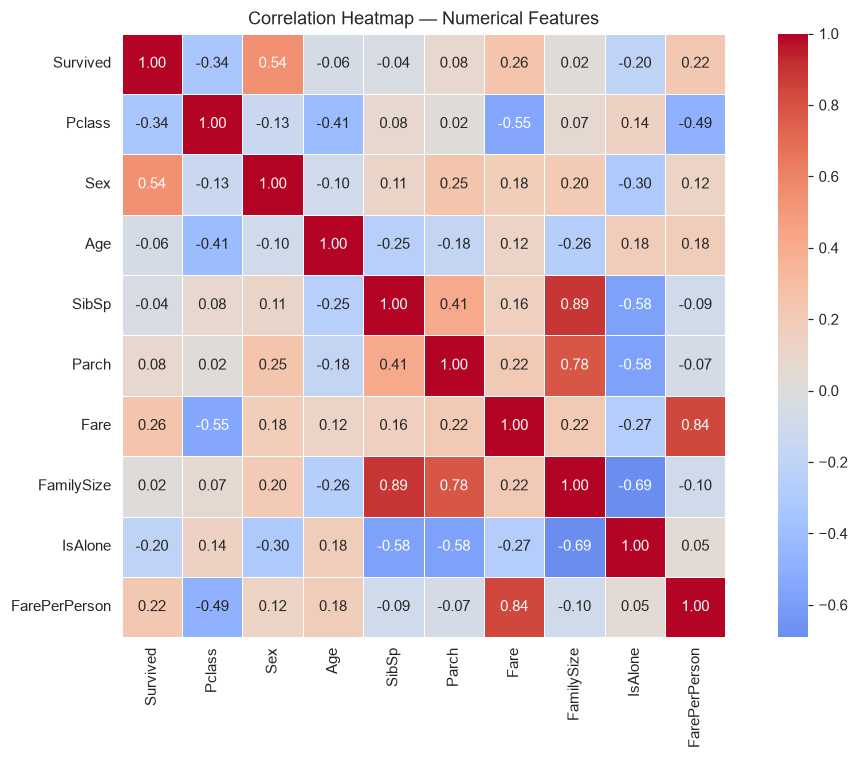

In [12]:
num_cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch",
            "Fare", "FamilySize", "IsAlone", "FarePerPerson"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.savefig("../charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 4. Bonus: Survival by Family Size

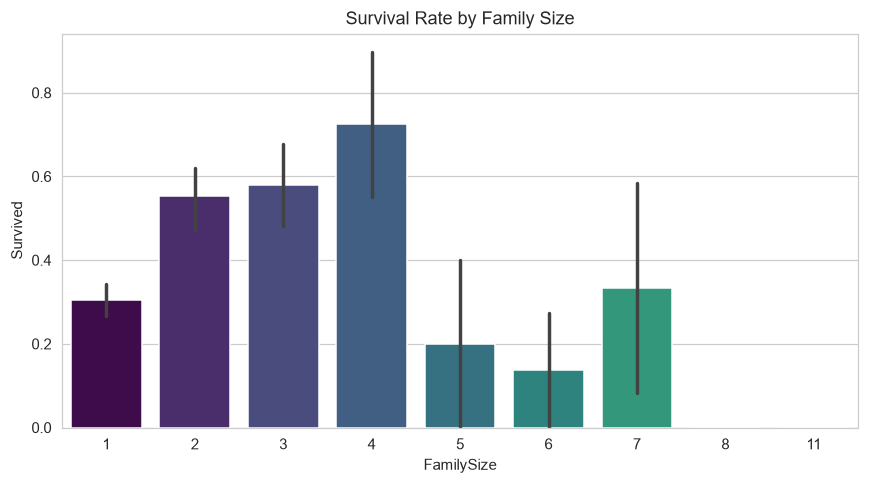

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x="FamilySize", y="Survived", data=df,
            hue="FamilySize", palette="viridis", legend=False, ax=ax)
ax.set_title("Survival Rate by Family Size")
plt.tight_layout()
plt.savefig("../charts/survival_by_family.png", bbox_inches="tight")
plt.show()

## Conclusion (3–5 lines)
1. Gender and passenger class are the dominant survival drivers (female & 1st class strongly favored).
2. Age shows a U-shaped survival pattern; children and young adults benefited most from evacuation priority.
3. Family size of 2–4 maximizes survival; solo travelers and large families had lower rates.
4. The cleaned dataset (no nulls, engineered features) is model-ready for logistic regression / tree-based classifiers.
5. Recommended features for modeling: Sex, Pclass, Age, FarePerPerson, FamilySize, IsAlone, Embarked.